**1. Data Exploration:**

In [18]:
import getpass

In [19]:
ngrok_key=getpass.getpass('enter key') ## we have to crate account on 'ngrok' api gaeway and token key copied

enter key··········


In [20]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 76.2 MB/s eta 0:00:00


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pickle

In [22]:
df=pd.read_csv('diabetes.csv')

In [23]:
df.shape

(768, 9)

In [24]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [26]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [27]:
#checking missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [28]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

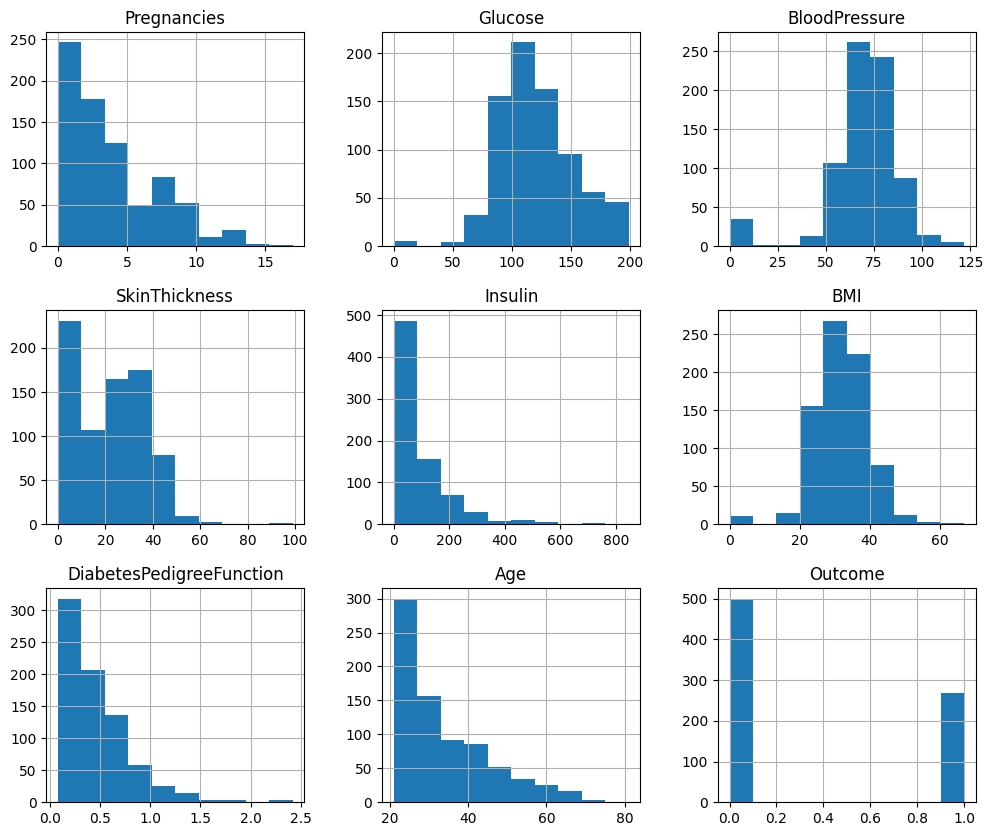

In [29]:
#histogram
df.hist(figsize=(12,10))
plt.show()

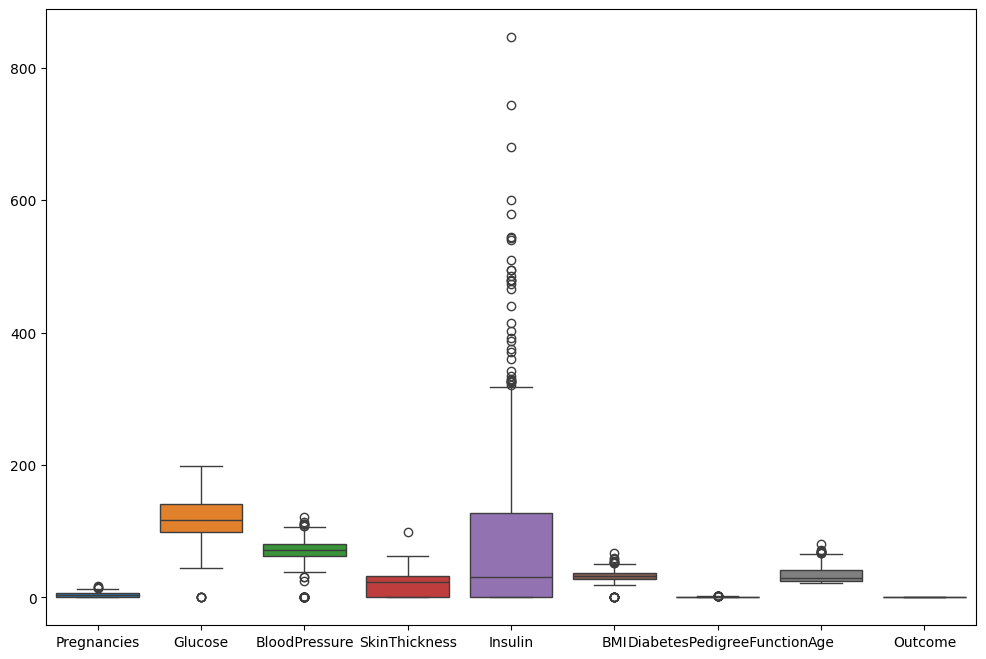

In [30]:
#identifing outliers
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.show()

In [31]:
# outliers treatment by capping
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    high_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else high_extreme if x>high_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

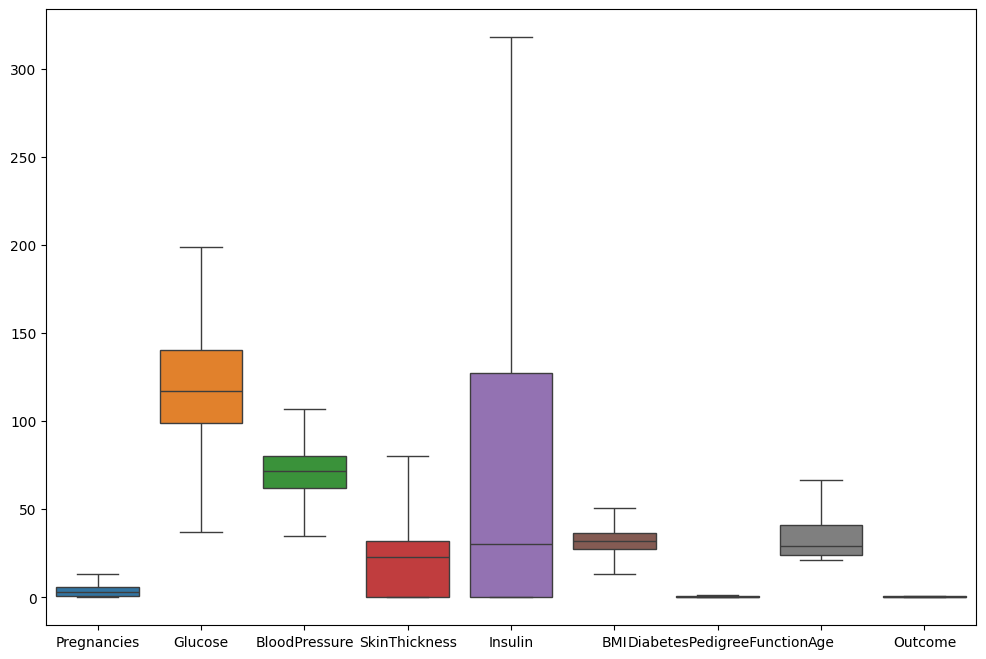

In [32]:
#verifing outliers are present or not
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.show()

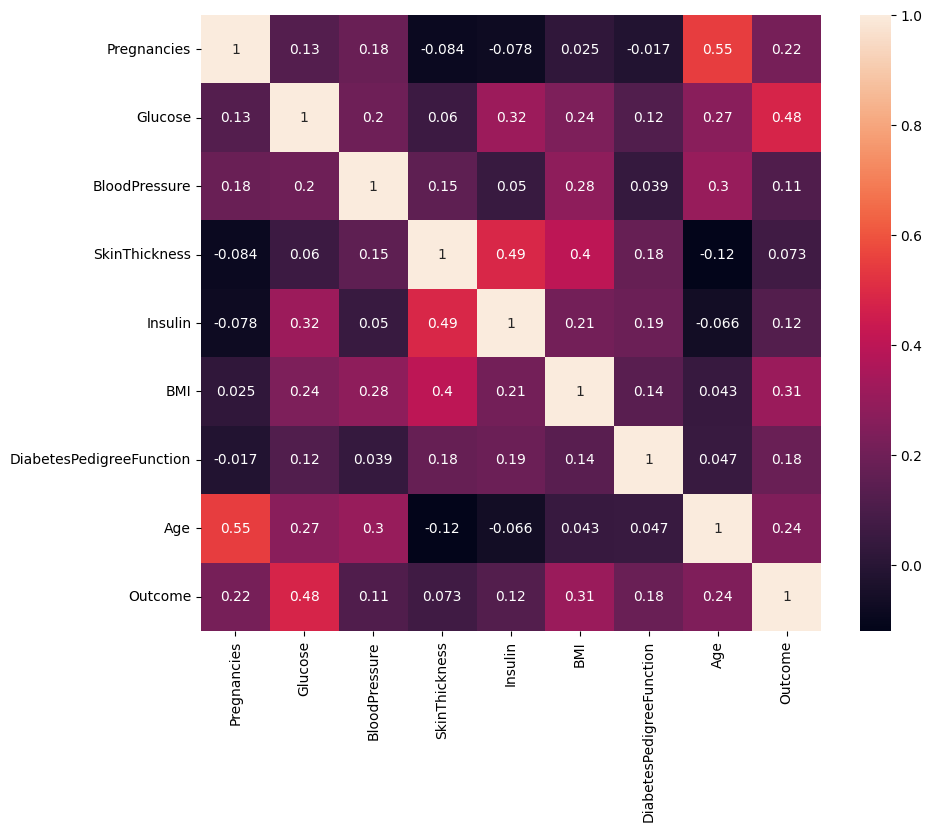

In [33]:
#correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

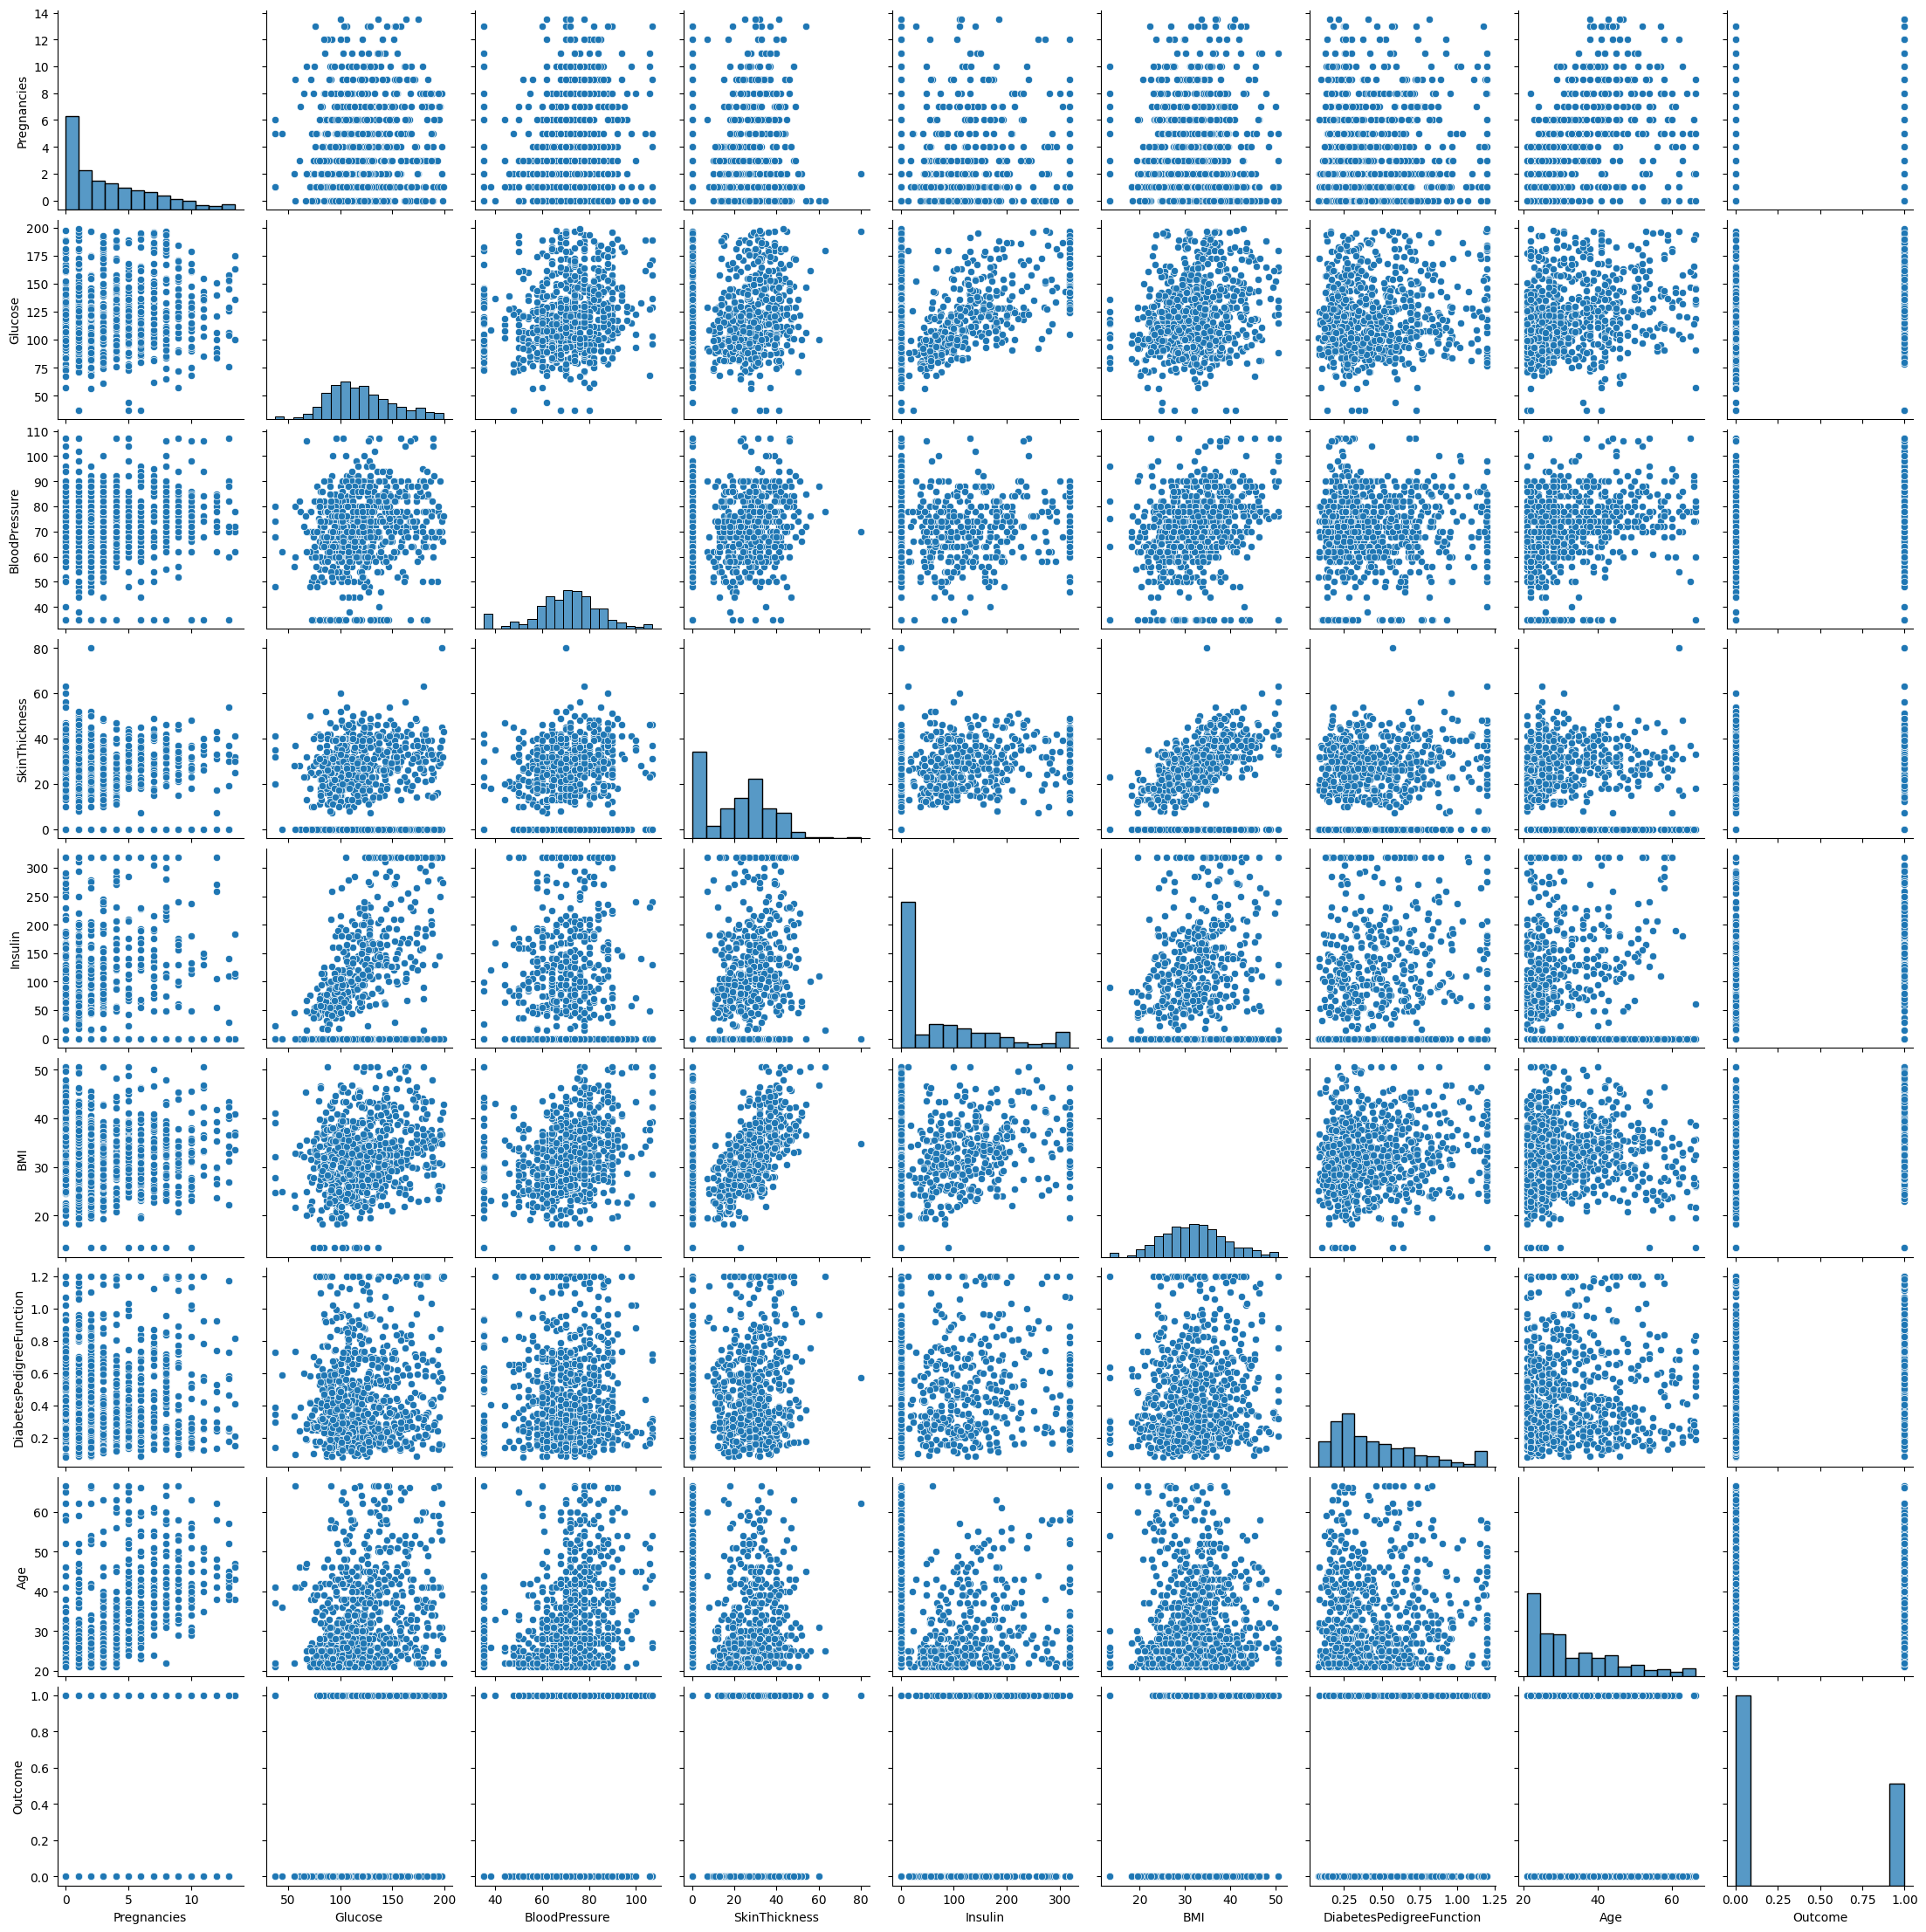

In [34]:
#pair plot
sns.pairplot(df)
plt.show()

**2. Data Preprocessing:**

In [35]:
#checking null values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [36]:
#there is no categorical columns to encode

In [37]:
features = df.drop('Outcome', axis=1)
target= df[['Outcome']]

In [38]:
x_train, x_test, y_train, y_test = train_test_split(features,target, test_size=0.2, random_state=50)

In [39]:
continuous_cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

scaler = StandardScaler()

x_train[continuous_cols] = scaler.fit_transform(x_train[continuous_cols])
x_test[continuous_cols] = scaler.transform(x_test[continuous_cols])

**3. Model Building:**

In [40]:

model = LogisticRegression()

# Train model
model.fit(x_train, y_train)

LogisticRegression()

**4. Model Evaluation:**

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,confusion_matrix,classification_report

# Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

In [42]:
testing_acc=accuracy_score(y_test,y_pred)
print('testing_accuracy',testing_acc)

testing_accuracy 0.7467532467532467


In [43]:
confusion_matrix(y_test,y_pred)

array([[89, 12],
       [27, 26]])

<Axes: >

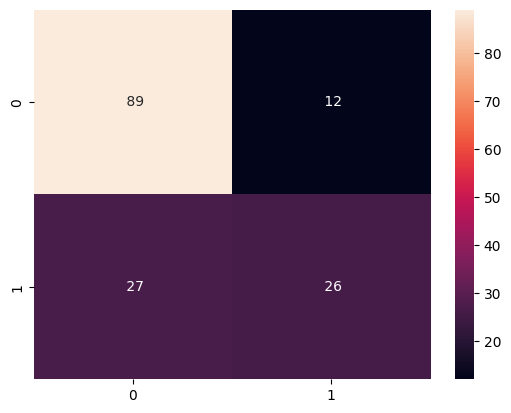

In [44]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='3.0f')

In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       101
           1       0.68      0.49      0.57        53

    accuracy                           0.75       154
   macro avg       0.73      0.69      0.70       154
weighted avg       0.74      0.75      0.73       154



In [46]:
roc_auc = roc_auc_score(y_test,y_pred)
print(roc_auc)

0.6858770782738651


In [47]:
fpr,tpr,thr=roc_curve(y_test,y_pred)

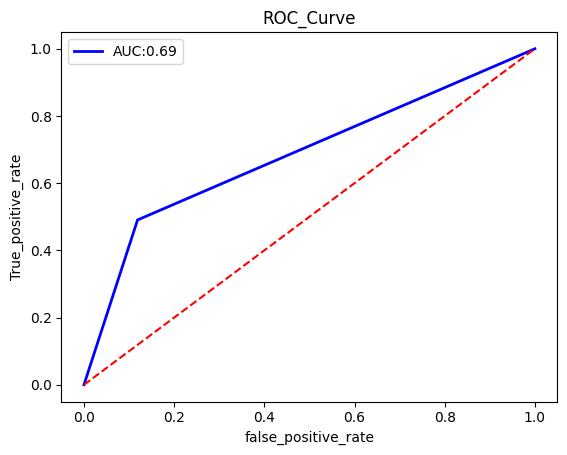

In [48]:
fpr,tpr,thr = roc_curve(y_test,y_pred)
plt.plot(fpr,tpr,lw=2,color='blue',label=f'AUC:{roc_auc:.2}')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('false_positive_rate')
plt.ylabel('True_positive_rate')
plt.title('ROC_Curve')
plt.legend()
plt.grid(False)

**5. Interpretation:**

In [49]:
#dataframe for coefficients

coeff_df = pd.DataFrame({
    'Feature': features.columns,
    'Coefficient': model.coef_[0]
})

# Sort coefficients
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)

print(coeff_df)

                    Feature  Coefficient
1                   Glucose     1.160976
5                       BMI     0.827177
6  DiabetesPedigreeFunction     0.353934
7                       Age     0.192693
0               Pregnancies     0.124309
3             SkinThickness    -0.099378
4                   Insulin    -0.112457
2             BloodPressure    -0.314251


In [50]:
file='model.pkl' #for model in input data modeling
pickle.dump(model,open(file,'wb'))

In [51]:
file='standscaler.pkl'  #for standisation in input data
pickle.dump(scaler,open(file,'wb'))

**6. Deployment with Streamlit:**

In [52]:
%%writefile app.py

# Import libraries
import pandas as pd
import numpy as np
import streamlit as st
import warnings
warnings.filterwarnings('ignore')

import pickle

# Load model and scaler
model = pickle.load(open('model.pkl', 'rb'))
std_scaler = pickle.load(open('standscaler.pkl', 'rb'))

# Title
st.title('Diabetes Prediction using Logistic Regression')

st.write("Enter patient details below")

# User Input Function
def user_input_parameters():

    pregnancies = st.sidebar.number_input(
        'Pregnancies',
        min_value=0,
        max_value=20,
        value=1
    )

    glucose = st.sidebar.number_input(
        'Glucose',
        min_value=0,
        max_value=300,
        value=120
    )

    blood_pressure = st.sidebar.number_input(
        'Blood Pressure',
        min_value=0,
        max_value=200,
        value=70
    )

    skin_thickness = st.sidebar.number_input(
        'Skin Thickness',
        min_value=0,
        max_value=100,
        value=20
    )

    insulin = st.sidebar.number_input(
        'Insulin',
        min_value=0,
        max_value=900,
        value=80
    )

    bmi = st.sidebar.number_input(
        'BMI',
        min_value=0.0,
        max_value=70.0,
        value=25.0
    )

    diabetes_pedigree = st.sidebar.number_input(
        'Diabetes Pedigree Function',
        min_value=0.0,
        max_value=3.0,
        value=0.5
    )

    age = st.sidebar.slider(
        'Age',
        min_value=1,
        max_value=100,
        value=30
    )

    # Create dataframe
    data = {
        'Pregnancies': pregnancies,
        'Glucose': glucose,
        'BloodPressure': blood_pressure,
        'SkinThickness': skin_thickness,
        'Insulin': insulin,
        'BMI': bmi,
        'DiabetesPedigreeFunction': diabetes_pedigree,
        'Age': age
    }

    features = pd.DataFrame(data, index=[0])

    # Continuous columns only
    continuous_cols = [
        'Glucose',
        'BloodPressure',
        'SkinThickness',
        'Insulin',
        'BMI',
        'DiabetesPedigreeFunction',
        'Age'
    ]

    # Scaling continuous columns
    features[continuous_cols] = std_scaler.transform(
        features[continuous_cols]
    )

    return features

# Get input dataframe
df = user_input_parameters()

# Prediction
pred = model.predict(df)

# Prediction probability
pred_prob = model.predict_proba(df)

# Button
button = st.button('Predict')

if button:

    st.subheader('Prediction Result')

    if pred[0] == 1:
        st.error('Patient is likely Diabetic')
    else:
        st.success('Patient is likely Non-Diabetic')

    st.subheader('Prediction Probability')

    st.write(pred_prob)

Writing app.py


**from this code of lines will generate a cloud link,copy and paste the link to verify**

In [53]:
from pyngrok import ngrok
port=8501
ngrok.set_auth_token(ngrok_key)
ngrok.connect(port).public_url

'https://recoil-roundup-stinger.ngrok-free.dev'

In [54]:
!rm -rf logs.txt && streamlit run app.py &>/content/logs.txt

**Interview Questions:**
# 1. What is the difference between precision and recall?

Precision measures how many predicted positive cases are actually positive.
Recall measures how many actual positive cases are correctly identified.
Precision focuses on reducing false positives.
Recall focuses on reducing false negatives.

# 2. What is cross-validation, and why is it important in binary classification?

Cross-validation is a technique used to evaluate model performance using different subsets of data.
The dataset is divided into multiple folds for training and testing.
It helps reduce overfitting and gives more reliable accuracy results.
In binary classification, it ensures the model performs well on unseen data.